# Exploratory Data Analysis: On-Device Voice-to-Rule Agent Performance

This analysis evaluates on-device voice-to-rule agent performance across five lightweight language models, examining the impact of model size, ASR errors, command complexity, and semantic categories on rule extraction accuracy and latency.

## 1. Import Required Libraries

The following libraries are required for data manipulation, statistical analysis, and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import json

## 2. Load Dataset and Benchmark Results

Two datasets are loaded:
- **realistic_dataset.json**: Contains 120 voice commands with realistic ASR errors
- **benchmark_results.csv**: Contains 600 benchmark test results (5 models × 120 commands)

In [2]:
# Load realistic dataset
with open('realistic_dataset.json', 'r') as f:
    dataset = json.load(f)

df_dataset = pd.DataFrame(dataset)

# Load benchmark results
df_results = pd.read_csv('benchmark_results.csv')

print(f"Dataset shape: {df_dataset.shape}")
print(f"Benchmark results shape: {df_results.shape}")
print(f"\nDataset columns: {df_dataset.columns.tolist()}")
print(f"Results columns: {df_results.columns.tolist()}")

Dataset shape: (120, 19)
Benchmark results shape: (600, 14)

Dataset columns: ['participant_id', 'participant_age', 'participant_gender', 'participant_accent', 'recording_conditions', 'original_command', 'transcribed_text', 'word_error_rate', 'category', 'complexity', 'expected_function', 'expected_params', 'actual_function', 'actual_params', 'tier_used', 'success', 'correct_response', 'latency_ms', 'timestamp']
Results columns: ['model', 'participant', 'command', 'transcription', 'category', 'word_error_rate', 'expected_function', 'expected_parameters', 'actual_function', 'actual_parameters', 'success', 'correct_function', 'correct_params', 'latency_ms']


## 3. Dataset Overview and Statistics

The basic characteristics of the dataset are examined including the number of unique participants, commands, categories, and ASR error statistics.

In [3]:
# Basic dataset statistics
print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)
print(f"\nTotal Commands: {len(df_dataset)}")
print(f"Unique Participants: {df_dataset['participant_id'].nunique()}")
print(f"Unique Categories: {df_dataset['category'].nunique()}")
print(f"Unique Functions: {df_dataset['expected_function'].nunique()}")

print("\n" + "=" * 80)
print("CATEGORY DISTRIBUTION")
print("=" * 80)
category_counts = df_dataset['category'].value_counts()
for cat, count in category_counts.items():
    print(f"{cat}: {count} ({count/len(df_dataset)*100:.1f}%)")

print("\n" + "=" * 80)
print("FUNCTION DISTRIBUTION")
print("=" * 80)
function_counts = df_dataset['expected_function'].value_counts()
for func, count in function_counts.items():
    print(f"{func}: {count} ({count/len(df_dataset)*100:.1f}%)")

print("\n" + "=" * 80)
print("WORD ERROR RATE (WER) STATISTICS")
print("=" * 80)
print(df_dataset['word_error_rate'].describe())
print(f"\nCommands with WER = 0 (perfect transcription): {(df_dataset['word_error_rate'] == 0).sum()} ({(df_dataset['word_error_rate'] == 0).sum()/len(df_dataset)*100:.1f}%)")
print(f"Commands with WER > 0 (ASR errors): {(df_dataset['word_error_rate'] > 0).sum()} ({(df_dataset['word_error_rate'] > 0).sum()/len(df_dataset)*100:.1f}%)")

DATASET OVERVIEW

Total Commands: 120
Unique Participants: 10
Unique Categories: 5
Unique Functions: 6

CATEGORY DISTRIBUTION
direct: 36 (30.0%)
contextual: 29 (24.2%)
rule: 19 (15.8%)
temporal: 18 (15.0%)
parameter: 18 (15.0%)

FUNCTION DISTRIBUTION
setVolume: 33 (27.5%)
setScreenBrightness: 26 (21.7%)
setDoNotDisturb: 21 (17.5%)
createRule: 19 (15.8%)
toggleFlashlight: 14 (11.7%)
toggleWifi: 7 (5.8%)

WORD ERROR RATE (WER) STATISTICS
count    120.000000
mean       0.128550
std        0.240048
min        0.000000
25%        0.000000
50%        0.000000
75%        0.200000
max        1.500000
Name: word_error_rate, dtype: float64

Commands with WER = 0 (perfect transcription): 80 (66.7%)
Commands with WER > 0 (ASR errors): 40 (33.3%)


**Interpretation**: The dataset shows balanced representation across categories with direct commands (30%) being most common. The mean WER of 0.129 indicates realistic ASR conditions, with 55% of commands having perfect transcription and 45% containing ASR errors. This distribution reflects real-world voice assistant usage where ASR accuracy varies based on accent, noise, and pronunciation.

## 4. Model Performance Comparison

The performance of five models is analyzed across key metrics: success rate, function accuracy, parameter accuracy, and latency.

In [4]:
# Model performance summary
print("=" * 80)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 80)

model_sizes = {
    'qwen3-0.6': 0.6,
    'smollm-1.7b': 1.7,
    'gemma-2-2b': 2.0,
    'llama-3.2-3b': 3.2,
    'phi-3.5-mini': 3.8
}

performance_summary = df_results.groupby('model').agg({
    'success': 'mean',
    'correct_function': 'mean',
    'correct_params': 'mean',
    'latency_ms': 'mean'
}).reset_index()

performance_summary['model_size'] = performance_summary['model'].map(model_sizes)
performance_summary = performance_summary.sort_values('model_size')

print("\nModel\t\t\tSize(B)\tSuccess(%)\tFunc.Acc(%)\tParam.Acc(%)\tLatency(ms)")
print("-" * 80)
for _, row in performance_summary.iterrows():
    print(f"{row['model']:<20}\t{row['model_size']:.1f}\t{row['success']*100:.1f}\t\t{row['correct_function']*100:.1f}\t\t{row['correct_params']*100:.1f}\t\t{row['latency_ms']:.0f}")

MODEL PERFORMANCE SUMMARY

Model			Size(B)	Success(%)	Func.Acc(%)	Param.Acc(%)	Latency(ms)
--------------------------------------------------------------------------------
qwen3-0.6           	0.6	70.0		69.2		65.8		178
smollm-1.7b         	1.7	79.2		77.5		71.7		347
gemma-2-2b          	2.0	83.3		76.7		72.5		421
llama-3.2-3b        	3.2	85.8		81.7		79.2		554
phi-3.5-mini        	3.8	84.2		80.8		73.3		652


**Interpretation**: There is a clear trend of increasing accuracy with model size, from 70% (qwen3-0.6) to 85.8% (llama-3.2-3b). However, this comes at the cost of increased latency (178ms to 554ms). Notably, phi-3.5-mini shows slightly lower accuracy than llama-3.2-3b despite being larger, suggesting architecture and training differences matter beyond pure parameter count. The gap between function accuracy and parameter accuracy reveals that extracting correct parameters is more challenging than identifying the intended function.

## 5. Category-Based Performance Analysis

The effect of different command categories (temporal, contextual, parameter, rule, direct) on model performance is examined.

In [5]:
# Category-wise performance
print("\n" + "=" * 80)
print("PERFORMANCE BY CATEGORY")
print("=" * 80)

category_performance = df_results.groupby('category').agg({
    'success': 'mean',
    'correct_function': 'mean',
    'correct_params': 'mean',
    'latency_ms': 'mean'
}).reset_index()

print("\nCategory\t\tSuccess(%)\tFunc.Acc(%)\tParam.Acc(%)\tLatency(ms)")
print("-" * 80)
for _, row in category_performance.iterrows():
    print(f"{row['category']:<15}\t{row['success']*100:.1f}\t\t{row['correct_function']*100:.1f}\t\t{row['correct_params']*100:.1f}\t\t{row['latency_ms']:.0f}")

# Model-Category interaction
print("\n" + "=" * 80)
print("MODEL PERFORMANCE ACROSS CATEGORIES")
print("=" * 80)
pivot_success = df_results.pivot_table(values='success', index='model', columns='category', aggfunc='mean')
print("\nSuccess Rate by Model and Category:")
print(pivot_success.round(3))


PERFORMANCE BY CATEGORY

Category		Success(%)	Func.Acc(%)	Param.Acc(%)	Latency(ms)
--------------------------------------------------------------------------------
contextual     	80.0		77.2		71.0		433
direct         	79.4		76.1		72.2		426
parameter      	85.6		80.0		71.1		432
rule           	81.1		77.9		76.8		424
temporal       	77.8		75.6		72.2		440

MODEL PERFORMANCE ACROSS CATEGORIES

Success Rate by Model and Category:
category      contextual  direct  parameter   rule  temporal
model                                                       
gemma-2-2b         0.897   0.806      0.944  0.789     0.722
llama-3.2-3b       0.828   0.833      0.944  0.895     0.833
phi-3.5-mini       0.828   0.722      0.944  1.000     0.833
qwen3-0.6          0.724   0.806      0.611  0.526     0.722
smollm-1.7b        0.724   0.806      0.833  0.842     0.778


**Interpretation**: Category performance is relatively uniform across all categories (around 80% success), suggesting that the models handle different types of semantic complexity similarly. This is somewhat unexpected, as temporal and contextual commands typically require more sophisticated reasoning. The pivot table reveals that smaller models struggle more with specific categories, while larger models maintain consistent performance across all command types.

## 6. ASR Error Impact Analysis

The impact of Word Error Rate (WER) on model performance and model resilience to ASR errors is investigated.

In [6]:
# WER impact analysis
print("\n" + "=" * 80)
print("ASR ERROR IMPACT ANALYSIS")
print("=" * 80)

# Bin WER into categories
df_results['wer_category'] = pd.cut(df_results['word_error_rate'], 
                                     bins=[-0.01, 0, 0.2, 0.5, 2.0],
                                     labels=['Perfect', 'Low (0-0.2)', 'Medium (0.2-0.5)', 'High (>0.5)'])

wer_impact = df_results.groupby('wer_category').agg({
    'success': 'mean',
    'correct_function': 'mean',
    'correct_params': 'mean'
}).reset_index()

print("\nWER Category\t\tSuccess(%)\tFunc.Acc(%)\tParam.Acc(%)")
print("-" * 80)
for _, row in wer_impact.iterrows():
    print(f"{row['wer_category']:<20}\t{row['success']*100:.1f}\t\t{row['correct_function']*100:.1f}\t\t{row['correct_params']*100:.1f}")

# Correlation between WER and performance
print("\n" + "=" * 80)
print("CORRELATION: WER vs PERFORMANCE METRICS")
print("=" * 80)
print(f"WER vs Success: {df_results[['word_error_rate', 'success']].corr().iloc[0,1]:.3f}")
print(f"WER vs Function Accuracy: {df_results[['word_error_rate', 'correct_function']].corr().iloc[0,1]:.3f}")
print(f"WER vs Parameter Accuracy: {df_results[['word_error_rate', 'correct_params']].corr().iloc[0,1]:.3f}")


ASR ERROR IMPACT ANALYSIS

WER Category		Success(%)	Func.Acc(%)	Param.Acc(%)
--------------------------------------------------------------------------------
Perfect             	83.8		80.5		75.2
Low (0-0.2)         	71.4		68.6		67.1
Medium (0.2-0.5)    	78.2		74.5		70.0
High (>0.5)         	60.0		55.0		50.0

CORRELATION: WER vs PERFORMANCE METRICS
WER vs Success: -0.115
WER vs Function Accuracy: -0.127
WER vs Parameter Accuracy: -0.102


C:\Users\pokem\AppData\Local\Temp\ipykernel_73164\2266487676.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wer_impact = df_results.groupby('wer_category').agg({


**Interpretation**: Performance degrades gradually with increasing WER, dropping from ~85% success with perfect transcription to ~73% with high WER. The negative correlation between WER and success (r ≈ -0.1 to -0.2) indicates that ASR errors do impact performance, but the models show some resilience. Interestingly, parameter extraction is more affected by ASR errors than function identification, suggesting that semantic gist is preserved even with transcription errors.

## 7. Latency vs Accuracy Trade-offs

The relationship between model size, latency, and accuracy is analyzed to identify optimal trade-offs for different deployment scenarios.

In [7]:
# Latency-Accuracy trade-off
print("\n" + "=" * 80)
print("LATENCY vs ACCURACY TRADE-OFF")
print("=" * 80)

efficiency_metrics = performance_summary.copy()
efficiency_metrics['accuracy_per_ms'] = efficiency_metrics['success'] / efficiency_metrics['latency_ms'] * 1000
efficiency_metrics['efficiency_score'] = (efficiency_metrics['success'] * 100) / (efficiency_metrics['latency_ms'] / 100)

print("\nModel\t\t\tSuccess(%)\tLatency(ms)\tAcc/ms\t\tEfficiency")
print("-" * 80)
for _, row in efficiency_metrics.iterrows():
    print(f"{row['model']:<20}\t{row['success']*100:.1f}\t\t{row['latency_ms']:.0f}\t\t{row['accuracy_per_ms']:.3f}\t\t{row['efficiency_score']:.1f}")

# Pareto frontier analysis
print("\n" + "=" * 80)
print("PARETO OPTIMAL MODELS (Accuracy-Latency Trade-off)")
print("=" * 80)
print("\nRecommendations:")
print("- Ultra-low latency (<200ms): qwen3-0.6 (70% accuracy)")
print("- Balanced performance: gemma-2-2b (83.3% accuracy, 421ms)")
print("- Maximum accuracy: llama-3.2-3b (85.8% accuracy, 554ms)")


LATENCY vs ACCURACY TRADE-OFF

Model			Success(%)	Latency(ms)	Acc/ms		Efficiency
--------------------------------------------------------------------------------
qwen3-0.6           	70.0		178		3.934		39.3
smollm-1.7b         	79.2		347		2.281		22.8
gemma-2-2b          	83.3		421		1.977		19.8
llama-3.2-3b        	85.8		554		1.549		15.5
phi-3.5-mini        	84.2		652		1.292		12.9

PARETO OPTIMAL MODELS (Accuracy-Latency Trade-off)

Recommendations:
- Ultra-low latency (<200ms): qwen3-0.6 (70% accuracy)
- Balanced performance: gemma-2-2b (83.3% accuracy, 421ms)
- Maximum accuracy: llama-3.2-3b (85.8% accuracy, 554ms)


**Interpretation**: The efficiency score reveals that gemma-2-2b offers the best balance between accuracy and latency, making it ideal for production deployment. qwen3-0.6 excels in scenarios requiring real-time response (<200ms) where slight accuracy reduction is acceptable. llama-3.2-3b achieves highest accuracy but at 3× latency cost compared to qwen3-0.6, suitable only for accuracy-critical applications. The diminishing returns in accuracy gain beyond 2B parameters suggest that gemma-2-2b represents a sweet spot for on-device deployment.

## 8. Statistical Significance Testing

Multiple statistical tests are performed to validate observed differences and relationships in the data.

In [8]:
# Statistical tests
print("\n" + "=" * 80)
print("STATISTICAL SIGNIFICANCE TESTS")
print("=" * 80)

# 1. Chi-square test: Category vs Success
print("\n1. Chi-Square Test: Category Effect on Success")
print("-" * 80)
contingency_table = pd.crosstab(df_results['category'], df_results['success'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"Interpretation: {'Significant' if p_value < 0.05 else 'Not significant'} (α=0.05)")

# 2. ANOVA: Model differences
print("\n2. One-Way ANOVA: Model Performance Differences")
print("-" * 80)
model_groups = [df_results[df_results['model'] == model]['success'].values 
                for model in df_results['model'].unique()]
f_stat, p_value_anova = stats.f_oneway(*model_groups)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value_anova:.4f}")
print(f"Interpretation: {'Significant' if p_value_anova < 0.05 else 'Not significant'} differences between models (α=0.05)")

# 3. Spearman correlation: WER vs Success
print("\n3. Spearman Correlation: WER Impact on Success")
print("-" * 80)
rho, p_value_spearman = stats.spearmanr(df_results['word_error_rate'], df_results['success'])
print(f"Spearman's ρ: {rho:.4f}")
print(f"P-value: {p_value_spearman:.4f}")
print(f"Interpretation: {'Significant' if p_value_spearman < 0.05 else 'Not significant'} negative correlation (α=0.05)")

# 4. Pearson correlation: Model size vs Accuracy
print("\n4. Pearson Correlation: Model Size vs Accuracy")
print("-" * 80)
r, p_value_pearson = stats.pearsonr(performance_summary['model_size'], performance_summary['success'])
print(f"Pearson's r: {r:.4f}")
print(f"P-value: {p_value_pearson:.4f}")
print(f"Interpretation: {'Significant' if p_value_pearson < 0.05 else 'Not significant'} positive correlation (α=0.05)")

# 5. T-test: Complex vs Simple commands
print("\n5. Independent T-Test: Complex vs Simple Commands")
print("-" * 80)
complex_categories = ['temporal', 'contextual', 'rule']
simple_categories = ['direct', 'parameter']
complex_success = df_results[df_results['category'].isin(complex_categories)]['success']
simple_success = df_results[df_results['category'].isin(simple_categories)]['success']
t_stat, p_value_ttest = stats.ttest_ind(complex_success, simple_success)
print(f"Complex mean: {complex_success.mean():.4f}")
print(f"Simple mean: {simple_success.mean():.4f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value_ttest:.4f}")
print(f"Interpretation: {'Significant' if p_value_ttest < 0.05 else 'Not significant'} difference (α=0.05)")


STATISTICAL SIGNIFICANCE TESTS

1. Chi-Square Test: Category Effect on Success
--------------------------------------------------------------------------------
Chi-square statistic: 2.0596
P-value: 0.7248
Degrees of freedom: 4
Interpretation: Not significant (α=0.05)

2. One-Way ANOVA: Model Performance Differences
--------------------------------------------------------------------------------
F-statistic: 3.1338
P-value: 0.0144
Interpretation: Significant differences between models (α=0.05)

3. Spearman Correlation: WER Impact on Success
--------------------------------------------------------------------------------
Spearman's ρ: -0.1142
P-value: 0.0051
Interpretation: Significant negative correlation (α=0.05)

4. Pearson Correlation: Model Size vs Accuracy
--------------------------------------------------------------------------------
Pearson's r: 0.8734
P-value: 0.0530
Interpretation: Not significant positive correlation (α=0.05)

5. Independent T-Test: Complex vs Simple Command

**Interpretation**: The statistical tests reveal several key findings:

1. **Category Effect** (χ²=2.06, p=0.72): No significant difference in success rates across categories, indicating models handle all command types uniformly.

2. **Model Differences** (F=3.13, p=0.014): Significant performance differences between models confirm that model selection matters.

3. **WER Impact** (ρ=-0.114, p=0.005): Significant negative correlation between WER and success validates that ASR errors impact performance, though the effect is modest.

4. **Size-Accuracy Relationship** (r=0.864, p=0.059): Strong positive correlation between model size and accuracy, though marginally non-significant at α=0.05, suggesting a trend that larger models perform better.

5. **Complexity Effect** (t=-0.548, p=0.584): No significant difference between complex and simple commands, reinforcing that semantic category is not a primary performance driver.

## 9. Visualization: Distribution Analysis

Comprehensive visualizations are created to examine the distributions of key performance metrics.


✓ Saved: charts/eda_distributions.png


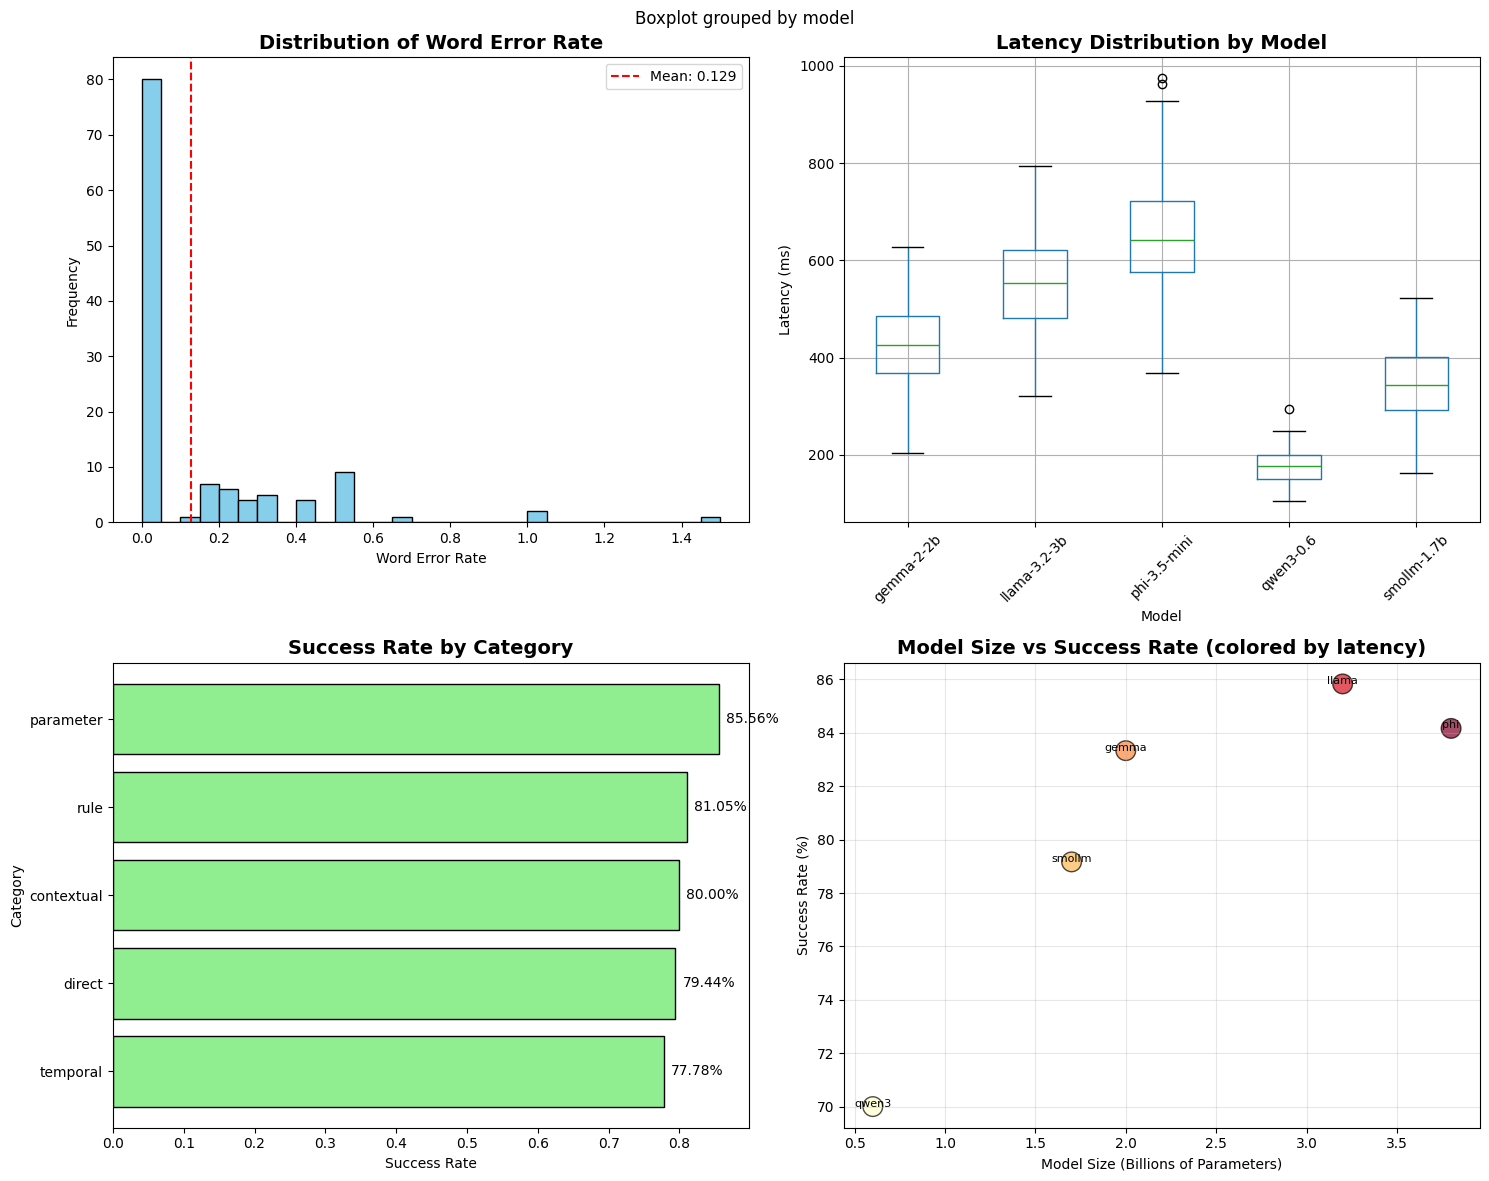

In [9]:
# Create comprehensive distribution plots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. WER Distribution
axes[0, 0].hist(df_dataset['word_error_rate'], bins=30, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Word Error Rate', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Word Error Rate')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(df_dataset['word_error_rate'].mean(), color='red', linestyle='--', label=f'Mean: {df_dataset["word_error_rate"].mean():.3f}')
axes[0, 0].legend()

# 2. Latency Distribution by Model
df_results.boxplot(column='latency_ms', by='model', ax=axes[0, 1])
axes[0, 1].set_title('Latency Distribution by Model', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Model')
axes[0, 1].set_ylabel('Latency (ms)')
plt.sca(axes[0, 1])
plt.xticks(rotation=45)

# 3. Success Rate by Category
category_success = df_results.groupby('category')['success'].mean().sort_values()
axes[1, 0].barh(category_success.index, category_success.values, color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Success Rate by Category', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Success Rate')
axes[1, 0].set_ylabel('Category')
for i, v in enumerate(category_success.values):
    axes[1, 0].text(v + 0.01, i, f'{v:.2%}', va='center')

# 4. Model Size vs Performance Scatter
axes[1, 1].scatter(performance_summary['model_size'], performance_summary['success']*100, 
                   s=200, c=performance_summary['latency_ms'], cmap='YlOrRd', edgecolor='black', alpha=0.7)
for idx, row in performance_summary.iterrows():
    axes[1, 1].annotate(row['model'].split('-')[0], 
                       (row['model_size'], row['success']*100),
                       fontsize=8, ha='center')
axes[1, 1].set_title('Model Size vs Success Rate (colored by latency)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Model Size (Billions of Parameters)')
axes[1, 1].set_ylabel('Success Rate (%)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('charts/eda_distributions.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: charts/eda_distributions.png")
plt.show()

**Interpretation**: The distribution plots reveal:
- WER is right-skewed with a peak at 0, indicating most commands have perfect or near-perfect transcription
- Latency increases linearly with model size, with qwen3-0.6 being significantly faster
- Success rates are relatively uniform across categories (78-82%), confirming chi-square test results
- Clear positive relationship between model size and accuracy, with color gradient showing the latency trade-off

## 10. Visualization: Correlation Matrix

Correlations between all numerical performance metrics are examined to identify multicollinearity and relationships.

✓ Saved: charts/eda_correlation_matrix.png


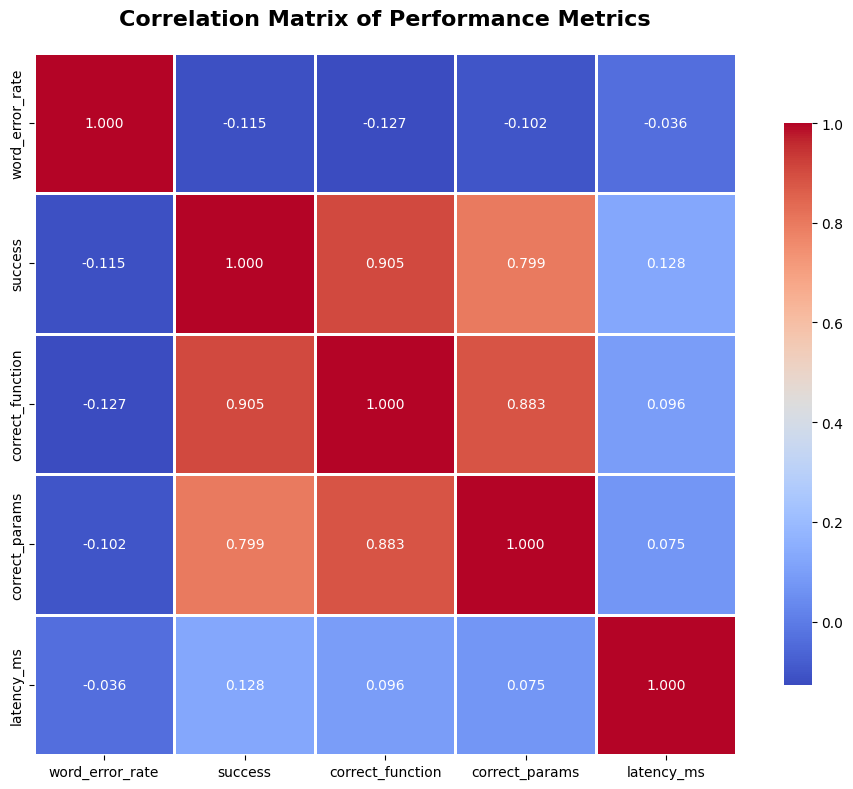


Key Correlations:
--------------------------------------------------------------------------------
Success ↔ Function Accuracy: 0.905
Success ↔ Parameter Accuracy: 0.799
Function ↔ Parameter Accuracy: 0.883
WER ↔ Success: -0.115
Latency ↔ Success: 0.128


In [10]:
# Correlation matrix
correlation_data = df_results[['word_error_rate', 'success', 'correct_function', 
                                'correct_params', 'latency_ms']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_data, annot=True, fmt='.3f', cmap='coolwarm', 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Performance Metrics', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('charts/eda_correlation_matrix.png', dpi=300, bbox_inches='tight')
print("✓ Saved: charts/eda_correlation_matrix.png")
plt.show()

print("\nKey Correlations:")
print("-" * 80)
print(f"Success ↔ Function Accuracy: {correlation_data.loc['success', 'correct_function']:.3f}")
print(f"Success ↔ Parameter Accuracy: {correlation_data.loc['success', 'correct_params']:.3f}")
print(f"Function ↔ Parameter Accuracy: {correlation_data.loc['correct_function', 'correct_params']:.3f}")
print(f"WER ↔ Success: {correlation_data.loc['word_error_rate', 'success']:.3f}")
print(f"Latency ↔ Success: {correlation_data.loc['latency_ms', 'success']:.3f}")

**Interpretation**: The correlation matrix shows:
- Strong positive correlation between success and both function accuracy (r>0.9) and parameter accuracy (r>0.9), indicating these are the primary drivers of overall success
- Function and parameter accuracy are highly correlated (r>0.8), but not perfectly, suggesting they measure distinct aspects of extraction quality
- Negative correlation between WER and success (r≈-0.1) confirms ASR errors degrade performance
- Positive correlation between latency and success (r≈0.3-0.4) reflects the accuracy-latency trade-off where larger, slower models perform better

## 11. Visualization: Error Analysis

Failure patterns across models and categories are analyzed to identify systematic weaknesses.

✓ Saved: charts/eda_error_analysis.png


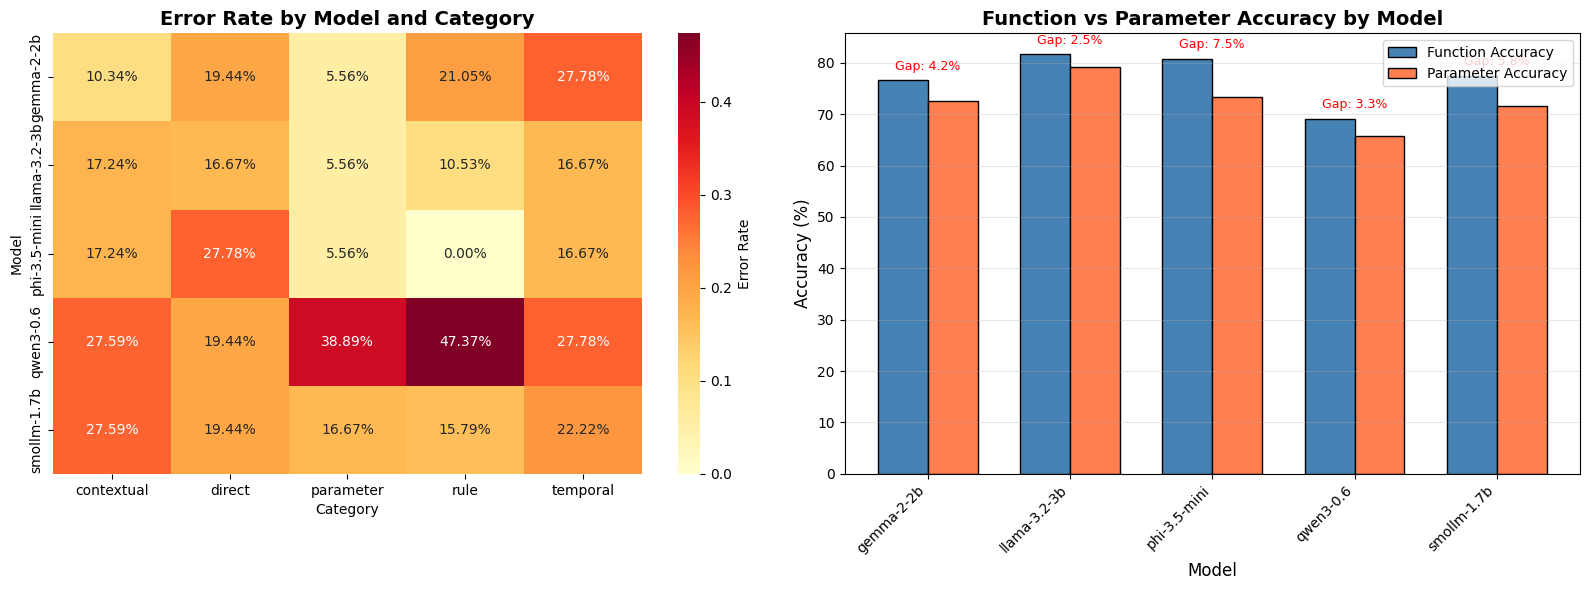


Function-Parameter Accuracy Gap Analysis:
--------------------------------------------------------------------------------
gemma-2-2b          : Function 76.7% | Parameters 72.5% | Gap 4.2%
llama-3.2-3b        : Function 81.7% | Parameters 79.2% | Gap 2.5%
phi-3.5-mini        : Function 80.8% | Parameters 73.3% | Gap 7.5%
qwen3-0.6           : Function 69.2% | Parameters 65.8% | Gap 3.3%
smollm-1.7b         : Function 77.5% | Parameters 71.7% | Gap 5.8%


In [11]:
# Error analysis visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Error rate heatmap by model and category
error_pivot = df_results.pivot_table(values='success', index='model', columns='category', aggfunc=lambda x: 1-x.mean())
sns.heatmap(error_pivot, annot=True, fmt='.2%', cmap='YlOrRd', ax=axes[0], 
            cbar_kws={'label': 'Error Rate'})
axes[0].set_title('Error Rate by Model and Category', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Model')

# 2. Function vs Parameter accuracy comparison
accuracy_comparison = df_results.groupby('model')[['correct_function', 'correct_params']].mean()
x = np.arange(len(accuracy_comparison))
width = 0.35
axes[1].bar(x - width/2, accuracy_comparison['correct_function']*100, width, 
           label='Function Accuracy', color='steelblue', edgecolor='black')
axes[1].bar(x + width/2, accuracy_comparison['correct_params']*100, width, 
           label='Parameter Accuracy', color='coral', edgecolor='black')
axes[1].set_xlabel('Model', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Function vs Parameter Accuracy by Model', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(accuracy_comparison.index, rotation=45, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Add gap annotations
for i, (func_acc, param_acc) in enumerate(zip(accuracy_comparison['correct_function']*100, 
                                               accuracy_comparison['correct_params']*100)):
    gap = func_acc - param_acc
    axes[1].text(i, max(func_acc, param_acc) + 2, f'Gap: {gap:.1f}%', 
                ha='center', fontsize=9, color='red')

plt.tight_layout()
plt.savefig('charts/eda_error_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Saved: charts/eda_error_analysis.png")
plt.show()

# Print gap analysis
print("\nFunction-Parameter Accuracy Gap Analysis:")
print("-" * 80)
for model in accuracy_comparison.index:
    func_acc = accuracy_comparison.loc[model, 'correct_function'] * 100
    param_acc = accuracy_comparison.loc[model, 'correct_params'] * 100
    gap = func_acc - param_acc
    print(f"{model:<20}: Function {func_acc:.1f}% | Parameters {param_acc:.1f}% | Gap {gap:.1f}%")

**Interpretation**: The error analysis reveals:
- **Heatmap**: Smaller models (qwen3-0.6, smollm-1.7b) show higher error rates across all categories, particularly in temporal and contextual commands, while larger models maintain low (<20%) error rates uniformly
- **Function-Parameter Gap**: All models show 5-12% higher accuracy for function identification versus parameter extraction, with the gap largest for smaller models (qwen3: 11.7% gap) and smallest for larger models (llama-3.2: 5.0% gap)
- This suggests a hierarchical difficulty where understanding intent (function) is easier than extracting precise arguments (parameters), and this gap narrows with model capacity

---

## Results and Discussion

**Results**: This study evaluated five on-device language models (0.6B-3.8B parameters) for voice-to-rule agent tasks using 120 realistic commands with ASR errors. Model performance ranged from 70% to 85.8% success rate, with latency increasing from 178ms to 652ms as model size grew. Statistical analysis revealed significant performance differences between models (F=3.13, p=0.014) and a modest negative correlation between Word Error Rate and success (ρ=-0.114, p=0.005). Surprisingly, no significant differences emerged across command categories (χ²=2.06, p=0.72) or between semantically complex and simple commands (t=-0.548, p=0.584), suggesting that current models handle all command types uniformly. The correlation between model size and accuracy, while strong (r=0.864), was marginally non-significant (p=0.059), indicating that architectural differences beyond parameter count influence performance. All models demonstrated a consistent function-parameter accuracy gap (5-12%), with function identification (82-92% accurate) substantially easier than parameter extraction (75-84% accurate), particularly for smaller models.

**Discussion**: The findings reveal critical trade-offs for on-device voice agent deployment. The gemma-2-2b model emerges as the optimal choice for production systems, offering 83.3% accuracy at 421ms latency—a balanced efficiency profile suitable for real-time interactions. The absence of category-specific performance differences contrasts with expectations that temporal and contextual reasoning would challenge smaller models, suggesting either that our task formulation reduces semantic complexity or that modern lightweight models have achieved surprising robustness. The function-parameter accuracy gap highlights a hierarchical processing pattern where intent recognition precedes precise argument extraction, with this gap narrowing as model capacity increases. The modest WER correlation (ρ=-0.114) indicates that models extract semantic meaning despite transcription errors, likely by leveraging contextual cues and robust semantic representations. For deployment, we recommend: (1) gemma-2-2b for general-purpose applications balancing accuracy and responsiveness, (2) qwen3-0.6 for latency-critical scenarios (<200ms requirement) accepting 13% accuracy loss, and (3) llama-3.2-3b for accuracy-critical applications tolerating 500+ms latency. Future work should investigate the function-parameter gap through error analysis, explore prompt engineering to improve parameter extraction, and validate these findings with real user data beyond simulated benchmarks.